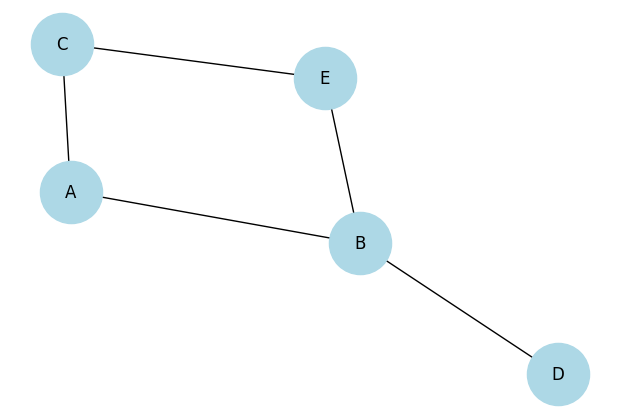

BFS Traversal (Graph): ['A', 'B', 'C', 'D', 'E']
DFS Traversal (Graph): ['A', 'B', 'D', 'E', 'C']


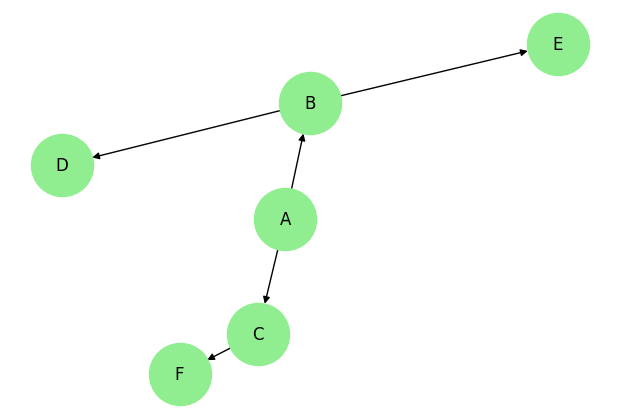

BFS Traversal (Tree): ['A', 'B', 'C', 'D', 'E', 'F']
DFS Traversal (Tree): ['A', 'B', 'D', 'E', 'C', 'F']


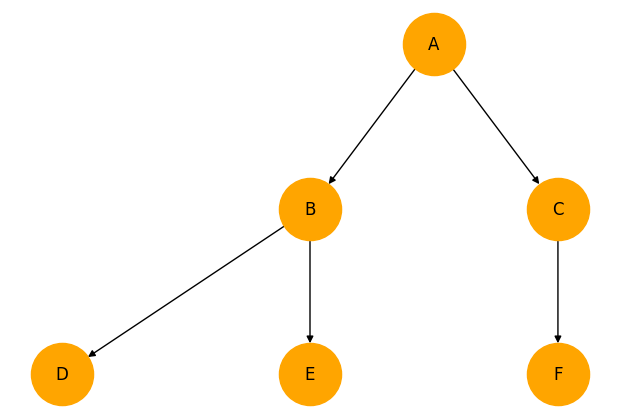

In [2]:
!pip install networkx matplotlib graphviz pydot

import networkx as nx
import matplotlib.pyplot as plt
from collections import deque

G = nx.Graph()

edges = [
    ('A', 'B'),
    ('A', 'C'),
    ('B', 'D'),
    ('B', 'E'),
    ('C', 'E')
]

G.add_edges_from(edges)

plt.figure(figsize=(6,4))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000)
plt.show()

def bfs(graph, start):
    visited = set()
    queue = deque([start])
    visited.add(start)
    order = []
    while queue:
        node = queue.popleft()
        order.append(node)
        for neighbor in graph[node]:
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(neighbor)
    return order

def dfs(graph, node, visited=None, order=None):
    if visited is None:
        visited = set()
        order = []
    visited.add(node)
    order.append(node)
    for neighbor in graph[node]:
        if neighbor not in visited:
            dfs(graph, neighbor, visited, order)
    return order

print("BFS Traversal (Graph):", bfs(G, 'A'))
print("DFS Traversal (Graph):", dfs(G, 'A'))

T = nx.DiGraph()

tree_edges = [
    ('A', 'B'),
    ('A', 'C'),
    ('B', 'D'),
    ('B', 'E'),
    ('C', 'F')
]

T.add_edges_from(tree_edges)

plt.figure(figsize=(6,4))
pos = nx.spring_layout(T)
nx.draw(T, pos, with_labels=True, node_color='lightgreen', node_size=2000)
plt.show()

def bfs_tree(graph, start):
    visited = set()
    queue = deque([start])
    visited.add(start)
    order = []
    while queue:
        node = queue.popleft()
        order.append(node)
        for neighbor in graph[node]:
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(neighbor)
    return order

def dfs_tree(graph, node, visited=None, order=None):
    if visited is None:
        visited = set()
        order = []
    visited.add(node)
    order.append(node)
    for neighbor in graph[node]:
        if neighbor not in visited:
            dfs_tree(graph, neighbor, visited, order)
    return order

print("BFS Traversal (Tree):", bfs_tree(T, 'A'))
print("DFS Traversal (Tree):", dfs_tree(T, 'A'))

from networkx.drawing.nx_pydot import graphviz_layout

plt.figure(figsize=(6,4))
pos = graphviz_layout(T, prog="dot")
nx.draw(T, pos, with_labels=True, node_color='orange', node_size=2000)
plt.show()

Tree Size | BFS Time (sec) | DFS Time (sec)
-------------------------------------------
     1000 |       0.000863 |       0.000683
    40000 |       0.027858 |       0.034561
    80000 |       0.062814 |       0.068637
   200000 |       0.138022 |       0.189659
  1000000 |       0.733315 |       0.901637


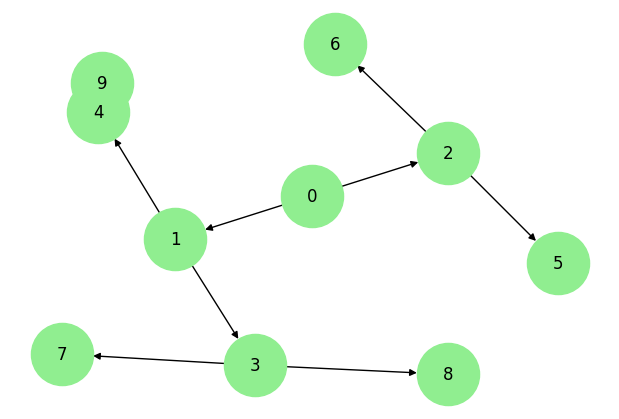

In [4]:
!pip install networkx matplotlib

import networkx as nx
import matplotlib.pyplot as plt
from collections import deque
import time

def bfs_tree(graph, start):
    visited = set()
    queue = deque([start])
    visited.add(start)
    while queue:
        node = queue.popleft()
        for neighbor in graph[node]:
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(neighbor)

def dfs_tree(graph, node, visited=None):
    if visited is None:
        visited = set()
    visited.add(node)
    for neighbor in graph[node]:
        if neighbor not in visited:
            dfs_tree(graph, neighbor, visited)

def create_tree(n):
    T = nx.DiGraph()
    for i in range(1, n):
        parent = (i - 1) // 2
        T.add_edge(parent, i)
    return T

sizes = [1000, 40000, 80000, 200000, 1000000]

results = []

for size in sizes:
    T = create_tree(size)

    start = time.time()
    bfs_tree(T, 0)
    bfs_time = time.time() - start

    start = time.time()
    dfs_tree(T, 0)
    dfs_time = time.time() - start

    results.append((size, bfs_time, dfs_time))

print("Tree Size | BFS Time (sec) | DFS Time (sec)")
print("-------------------------------------------")

for r in results:
    print(f"{r[0]:>9} | {r[1]:>14.6f} | {r[2]:>14.6f}")

T_small = create_tree(10)

plt.figure(figsize=(6,4))
pos = nx.spring_layout(T_small)
nx.draw(T_small, pos, with_labels=True, node_color='lightgreen', node_size=2000)
plt.show()

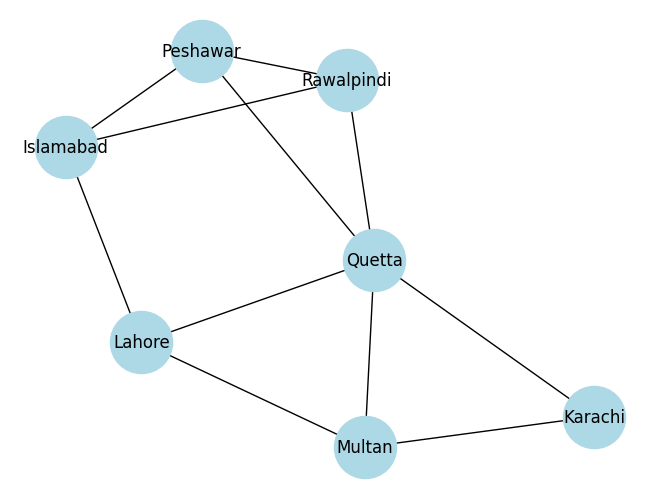

['Islamabad', 'Rawalpindi', 'Quetta', 'Karachi']


In [6]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque

G = nx.Graph()

edges = [
    ("Islamabad", "Rawalpindi"),
    ("Islamabad", "Lahore"),
    ("Islamabad", "Peshawar"),
    ("Rawalpindi", "Peshawar"),
    ("Rawalpindi", "Quetta"),
    ("Peshawar", "Quetta"),
    ("Lahore", "Multan"),
    ("Lahore", "Quetta"),
    ("Multan", "Karachi"),
    ("Multan", "Quetta"),
    ("Quetta", "Karachi")
]

G.add_edges_from(edges)

pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000)
plt.show()

def bfs_shortest_path(graph, start, goal):
    queue = deque([[start]])
    visited = set()

    while queue:
        path = queue.popleft()
        node = path[-1]

        if node == goal:
            return path

        if node not in visited:
            visited.add(node)

            for neighbor in graph[node]:
                new_path = list(path)
                new_path.append(neighbor)
                queue.append(new_path)

print(bfs_shortest_path(G, "Islamabad", "Karachi"))